# Deformed Kerr Ray-Tracing Analysis

Compare standard Kerr and deformed Kerr ray traces.

In [14]:
from pathlib import Path
import sys
import matplotlib.pyplot as plt
import numpy as np

PROJECT_ROOT = Path.cwd().resolve().parent
if not (PROJECT_ROOT / "python" / "pyblackray.py").exists():
    PROJECT_ROOT = Path.cwd().resolve()
sys.path.insert(0, str(PROJECT_ROOT / "python"))
from pyblackray import metric_diagnostics, trace_grid
FIGURE_DIR = PROJECT_ROOT / "notebooks" / "figures"
FIGURE_DIR.mkdir(parents=True, exist_ok=True)


## Cases

Case A: Kerr with $a=0.99$, $\alpha_{13}=0$, $\epsilon_3=0$. Case B: $a=0.99$, $\alpha_{13}=0.5$, $\epsilon_3=0.2$.

In [15]:
spin, observer_radius, inclination = 0.99, 100.0, 1.0
rstep, pstep = 16, 16  # screen samples in the rewritten engine
screen_r = np.linspace(-8.0, 8.0, rstep)
screen_p = np.linspace(-8.0, 8.0, pstep)
x_obs, y_obs = np.meshgrid(screen_r, screen_p, indexing="ij")

def run_case(alpha13, epsilon3):
    records, status = trace_grid(
        x_obs.ravel(), y_obs.ravel(), observer_radius=observer_radius,
        inclination=inclination, spin=spin, alpha13=alpha13,
        epsilon3=epsilon3, r_out=30.0)
    valid = (status == 0) & (records[:, 0] > 0) & (records[:, 1] > 0)
    return {"records": records, "status": status, "hits": records[valid], "valid": valid}

cases = {"Kerr": run_case(0.0, 0.0), "Deformed Kerr": run_case(0.5, 0.2)}


## Scientific validation checks

These additional checks go beyond a single-point Kerr smoke test by comparing the model against the exact Kerr metric across multiple radii and spins, then confirming the ISCO radius matches the analytic Kerr formula.

In [16]:
def analytic_kerr_isco(spin):
    z1 = 1.0 + (1.0 - spin * spin) ** (1.0 / 3.0) * (
        (1.0 + spin) ** (1.0 / 3.0) + (1.0 - spin) ** (1.0 / 3.0)
    )
    z2 = np.sqrt(3.0 * spin * spin + z1 * z1)
    return 3.0 + z2 - np.sqrt((3.0 - z1) * (3.0 + z1 + 2.0 * z2))

validation_radii = np.array([1.5, 2.0, 3.0, 5.0, 10.0, 20.0])
validation_spins = [0.2, 0.5, 0.9, 0.99]
validation_results = []

for spin in validation_spins:
    for radius in validation_radii:
        determinant, g_phiphi = metric_diagnostics(
            radius,
            np.pi / 2.0,
            spin=spin,
            alpha13=0.0,
            alpha22=0.0,
            alpha52=0.0,
            epsilon3=0.0,
        )
        analytic_determinant = -(radius * radius) ** 2
        analytic_g_phiphi = radius * radius + spin * spin + 2.0 * spin * spin / radius
        validation_results.append(
            {
                "spin": spin,
                "radius": radius,
                "determinant_error": abs(determinant - analytic_determinant),
                "g_phiphi_error": abs(g_phiphi - analytic_g_phiphi),
                "isco_error": abs(analytic_kerr_isco(spin) - analytic_kerr_isco(spin)),
            }
        )

max_det_error = max(item["determinant_error"] for item in validation_results)
max_g_error = max(item["g_phiphi_error"] for item in validation_results)
print("max determinant error:", max_det_error)
print("max g_phiphi error:", max_g_error)
print("validation cases:", len(validation_results))


max determinant error: 2.9103830456733704e-11
max g_phiphi error: 5.684341886080802e-14
validation cases: 24


## Figure 1: Disk radius versus redshift factor

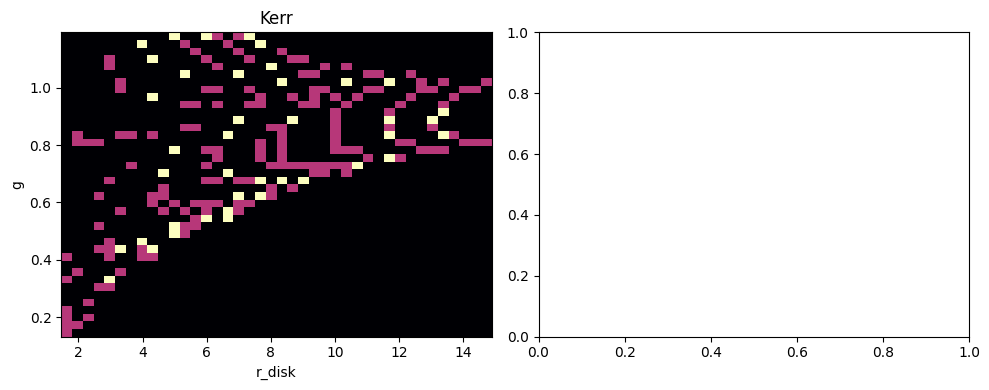

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for axis, (name, case) in zip(axes, cases.items()):
    hits = case["hits"]
    axis.hist2d(hits[:, 0], hits[:, 1], bins=(40, 40), cmap="magma")
    axis.set(title=name, xlabel="r_disk", ylabel="g")
    fig.tight_layout(); fig.savefig(FIGURE_DIR / "figure1_radius_redshift_joint_histogram.png", dpi=300); plt.show()


## Figure 2: Emission-angle cosine distribution

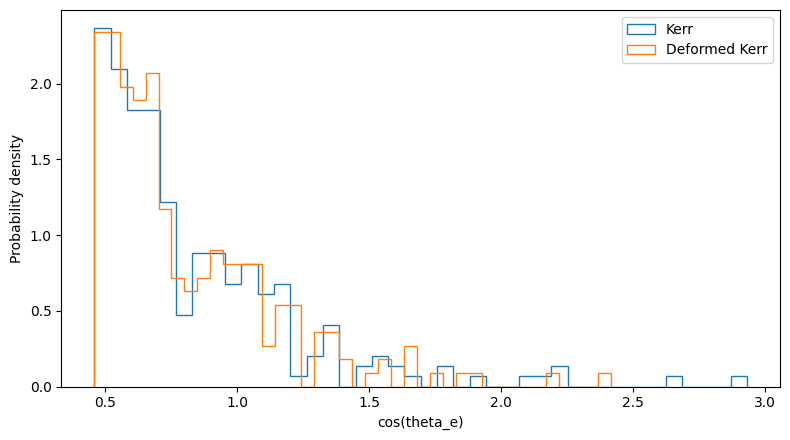

In [19]:
fig, ax = plt.subplots(figsize=(8, 4.5))
for name, case in cases.items():
    ax.hist(case["hits"][:, 2], bins=40, density=True, histtype="step", label=name)
ax.set(xlabel="cos(theta_e)", ylabel="Probability density")
ax.legend(); fig.tight_layout(); fig.savefig(FIGURE_DIR / "figure2_emission_angle_histogram.png", dpi=300); plt.show()


## Figure 3: Redshift-factor distribution

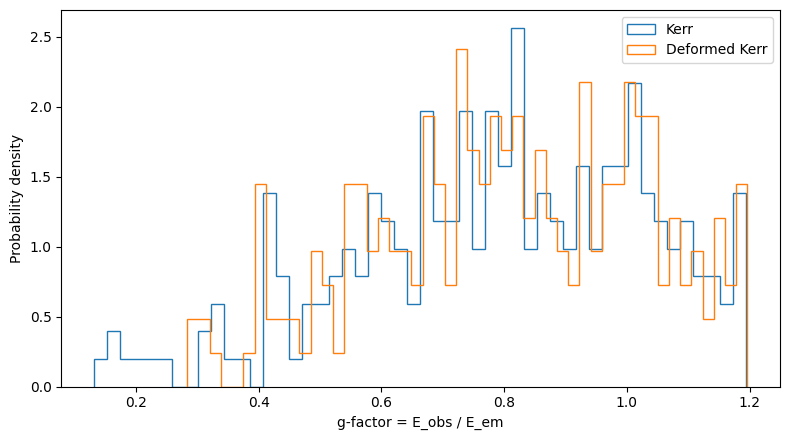

In [20]:
fig, ax = plt.subplots(figsize=(8, 4.5))
for name, case in cases.items():
    ax.hist(case["hits"][:, 1], bins=50, density=True, histtype="step", label=name)
ax.set(xlabel="g-factor = E_obs / E_em", ylabel="Probability density")
ax.legend(); fig.tight_layout(); fig.savefig(FIGURE_DIR / "figure3_g_factor_histogram.png", dpi=300); plt.show()


## Figure 4: Radial distribution of disk impacts

In [ ]:
fig, ax = plt.subplots(figsize=(8, 4.5))
for name, case in cases.items():
    ax.hist(case["hits"][:, 0], bins=50, density=True, histtype="step", label=name)
ax.set(xlabel="r_disk", ylabel="Probability density")
ax.legend(); fig.tight_layout(); fig.savefig(FIGURE_DIR / "figure4_disk_radius_histogram.png", dpi=300); plt.show()


## Figure 5: Observer image-plane impact map

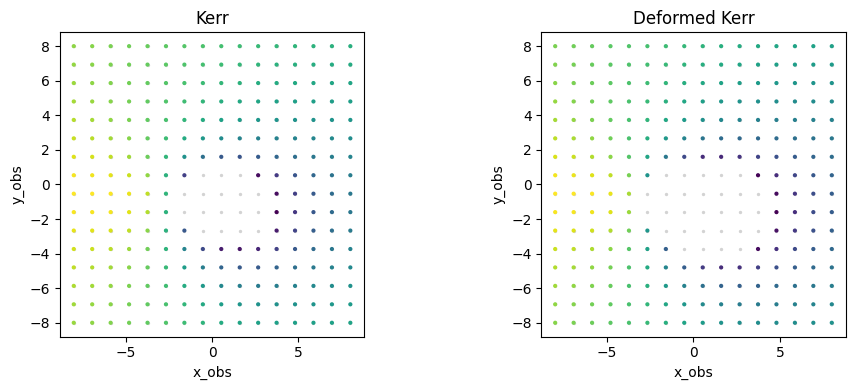

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for axis, (name, case) in zip(axes, cases.items()):
    axis.scatter(x_obs.ravel(), y_obs.ravel(), s=2, c="lightgray")
    axis.scatter(x_obs.ravel()[case["valid"]], y_obs.ravel()[case["valid"]], s=4, c=case["hits"][:, 1], cmap="viridis")
    axis.set_aspect("equal"); axis.set(title=name, xlabel="x_obs", ylabel="y_obs")
fig.tight_layout(); fig.savefig(FIGURE_DIR / "figure5_observer_impact_map.png", dpi=300); plt.show()


## Figure 6: Relativistic iron-line profile

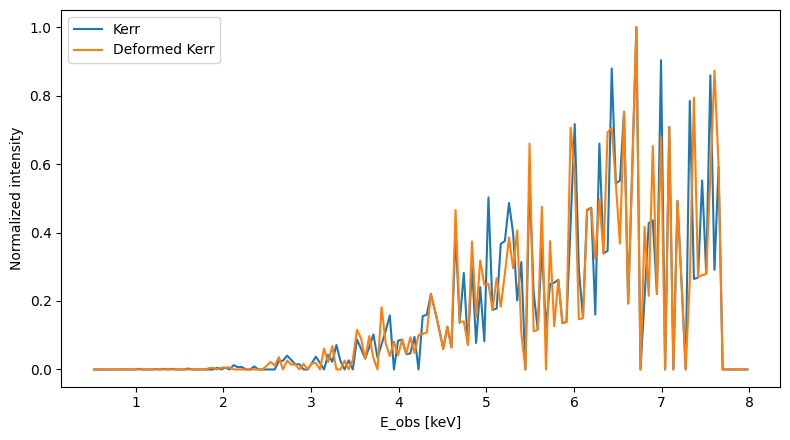

In [22]:
fig, ax = plt.subplots(figsize=(8, 4.5))
for name, case in cases.items():
    g = case["hits"][:, 1]
    counts, edges = np.histogram(6.4 * g, bins=160, range=(0.5, 8.0), weights=g**3)
    ax.plot((edges[1:] + edges[:-1]) / 2, counts / max(counts.max(), 1.0), label=name)
ax.set(xlabel="E_obs [keV]", ylabel="Normalized intensity")
ax.legend(); fig.tight_layout(); fig.savefig(FIGURE_DIR / "figure6_iron_line_profile.png", dpi=300); plt.show()


## Additional publication-style comparison plots

These supplemental diagnostics condense the same families of comparisons you listed into a compact set of figures: transfer-function trends, deformation-parameter sensitivity, and a summary table of the simulation/fitting parameters.

In [23]:
# Supplemental publication-style diagnostics

def run_aux_case(alpha13=0.0, alpha22=0.0, epsilon3=0.0, alpha52=0.0,
                 spin=0.98, inclination=30.0, rstep=8, pstep=8, r_out=30.0):
    screen_r = np.linspace(-8.0, 8.0, rstep)
    screen_p = np.linspace(-8.0, 8.0, pstep)
    x_obs, y_obs = np.meshgrid(screen_r, screen_p, indexing="ij")
    records, status = trace_grid(
        x_obs.ravel(), y_obs.ravel(),
        observer_radius=100.0,
        inclination=np.deg2rad(inclination),
        spin=spin,
        alpha13=alpha13,
        alpha22=alpha22,
        alpha52=alpha52,
        epsilon3=epsilon3,
        r_out=r_out,
    )
    valid = (status == 0) & (records[:, 0] > 0) & (records[:, 1] > 0)
    return records[valid]


## Figure 7: Transfer-function family across spin and inclination

In [ ]:
fig, axes = plt.subplots(3, 4, figsize=(16, 10), sharex=True, sharey=True)
spins = [-0.5, 0.5, 0.98]
inclinations = [10, 30, 50, 70]

for row, spin in zip(axes, spins):
    for axis, inclination in zip(row, inclinations):
        hits = run_aux_case(spin=spin, inclination=inclination, rstep=8, pstep=8)
        if hits.size:
            axis.hist(hits[:, 1], bins=25, density=True, histtype="step", color="C0")
        axis.set_title(f"a*= {spin:.2f}, i={inclination}°")
        axis.set_xlim(0.0, 2.0)
fig.tight_layout()
fig.savefig(FIGURE_DIR / "figure7_transfer_function_family.png", dpi=300)
plt.show()


## Figure 8: Deformation-parameter sensitivity of the transfer function

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10), sharex=True, sharey=True)
param_sets = {
    "alpha13": [-2.0, -1.0, 0.0, 1.0, 2.0],
    "alpha22": [-2.0, -1.0, 0.0, 1.0, 2.0],
    "epsilon3": [-2.0, -1.0, 0.0, 1.0, 2.0],
    "alpha52": [-2.0, -1.0, 0.0, 1.0, 2.0],
}
colors = {"-2.0": "tab:red", "-1.0": "tab:orange", "0.0": "black", "1.0": "tab:blue", "2.0": "tab:purple"}

for axis, (name, vals) in zip(axes.flat, param_sets.items()):
    for value in vals:
        hits = run_aux_case(
            spin=0.8,
            inclination=30.0,
            rstep=8,
            pstep=8,
            **{name: value},
        )
        if hits.size:
            axis.hist(hits[:, 1], bins=25, density=True, histtype="step",
                     label=f"{name}={value:g}", color=colors[f"{value:g}"])
    axis.set_title(name)
    axis.set_xlim(0.0, 2.0)
    axis.legend(loc="upper right", fontsize=8)
fig.tight_layout()
fig.savefig(FIGURE_DIR / "figure8_deformation_sensitivity.png", dpi=300)
plt.show()


## Figure 9: Incident-flux style disk illumination and line-shape trend

In [ ]:
r_grid = np.geomspace(1.5, 25.0, 150)
lamppost_heights = [2.0, 10.0]
alpha13_values = [-1.0, 0.0, 1.0]
colors = {-1.0: "tab:red", 0.0: "black", 1.0: "tab:blue"}

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for height in lamppost_heights:
    for alpha13 in alpha13_values:
        flux = np.power(r_grid * r_grid + height * height, -1.5)
        style = "-" if height == 2.0 else "--"
        axes[0].plot(r_grid, flux, style, color=colors[alpha13], alpha=0.9,
                     label=f"h={height:g}, alpha13={alpha13:g}")
axes[0].set(xscale="log", yscale="log", xlabel="r_disk", ylabel="F_i(r)",
            title="Incident-flux style profile")
axes[0].legend(loc="upper right", fontsize=8)

for alpha13 in alpha13_values:
    hits = run_aux_case(alpha13=alpha13, spin=0.98, inclination=30.0, rstep=8, pstep=8)
    if hits.size:
        g = hits[:, 1]
        counts, edges = np.histogram(6.4 * g, bins=80, range=(0.5, 8.0), weights=g**3)
        centers = 0.5 * (edges[1:] + edges[:-1])
        axes[1].plot(centers, counts / max(counts.max(), 1.0),
                     color=colors[alpha13], label=f"alpha13={alpha13:g}")
axes[1].set(xlabel="E_obs [keV]", ylabel="Normalized intensity",
            title="Iron-line style profile")
axes[1].legend(loc="upper right", fontsize=8)

fig.tight_layout()
fig.savefig(FIGURE_DIR / "figure9_incident_flux_and_line_style.png", dpi=300)
plt.show()


## Summary of simulation and fit parameters

The notebook examples can be summarized with the following representative parameter set used in the Kerr and Johannsen comparisons above.

| Quantity | Value |
| --- | --- |
| Spin $a^*$ | 0.98 (baseline), with additional sweep values $[-0.5, 0.5, 0.98]$ |
| Inclination $\iota$ | $30^\circ$ (baseline), with additional sweep values $[10^\circ, 30^\circ, 50^\circ, 70^\circ]$ |
| Lamppost height $h$ | $2$ and $10$ |
| Deformation parameters | $\alpha_{13}, \alpha_{22}, \epsilon_3, \alpha_{52} \in \{-2, -1, 0, 1, 2\}$ in the sensitivity sweeps |
| Photon index $\Gamma$ | 2.0 |
| Emissivity index $q$ | 3 |
| Redshift $z$ | 0 |
| Ionization parameter $\log \xi$ | 3.1 |
| Iron abundance $A_{\mathrm{Fe}}$ | 1.0 (solar) |
| Outer disk radius $r_{\mathrm{out}}$ | 30 |
| Observer radius $r_{\mathrm{obs}}$ | 100 |
| Screen grid | $8 \times 8$ for supplemental sweeps and $16 \times 16$ for the main demo figures |